In [7]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

In [7]:
Scenario = 'Scenario_B'
ML_model = 'LightGBM_001'

### Functions

In [8]:
def predict_LGBM(model, X_df, y_df, prediction_col='ETa_predicted'):

    
    preds = model.predict(X_df)
    
    # Create a copy of the DataFrame and add the predictions column.
    df_with_preds = pd.concat([X_df, y_df], axis=1).copy()
    df_with_preds[prediction_col] = preds
    
    return df_with_preds

## Model training

In [9]:
train_file_UC1 = os.path.join(os.path.dirname(os.getcwd()),'6_Data_aggregation',
                             'US_UC1_Hourly_ECT_PSNDVI_ETa.csv')  # Change to your training file path

train_file_UC2 = os.path.join(os.path.dirname(os.getcwd()),'6_Data_aggregation',
                             'US_UC2_Hourly_ECT_PSNDVI_ETa.csv')  # Change to your training file path

# Load the data; ensure that the timestamp column is parsed as dates.
UC1_train_df = pd.read_csv(train_file_UC1, index_col=0, parse_dates=[0])
UC2_train_df = pd.read_csv(train_file_UC2, index_col=0, parse_dates=[0])

train_df = pd.concat([UC1_train_df, UC2_train_df])

# Drop observations with nan NDVI values or ET_corr nan values
train_df_filtered = train_df[(train_df['NDVI']>0) & (train_df['ETa_corr']>0)]

train_df_filtered = train_df_filtered.rename(columns={'TA': 'Air Temperature', 'RH': 'relative_humidity',
                                                      'SW_IN':'Downward Short-Wave Radiation Flux',
                                                      'LW_IN':'Downward Long-Wave Radiation Flux',
                                                      'WS':'Wind Speed', 'PA':'Air Pressure',
                                                      'P_RAIN':'Total Precipitation'})

# Drop 'Downward Long-Wave Radiation Flux' and 'Total Precipitation' based on HXGB001 results
train_df_filtered = train_df_filtered.drop(columns=['Downward Long-Wave Radiation Flux', 'Total Precipitation', 'Wind Speed', 'Air Pressure'])

# train X and y
X_train_val = train_df_filtered.drop(columns=['ETa_corr', 'ETa_NaN_flag']).round(2)  # Training features
y_train_val = train_df_filtered['ETa_corr'].round(3)  # Training target

In [10]:
def objective(trial):
    # Choose between two objectives: standard regression or huber loss for robustness.
    objective_choice = trial.suggest_categorical('objective', ['regression', 'huber'])
    
    param = {
        'objective': objective_choice,
        'metric': 'mae',
        'learning_rate': round(trial.suggest_float('learning_rate', 0.001, 0.1, log=True),3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 25),
        'min_data_in_leaf': 25,
        'feature_fraction': round(trial.suggest_float('feature_fraction', 0.1, 1.0),3),
        'bagging_fraction': round(trial.suggest_float('bagging_fraction', 0.1, 1.0),3),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1': round(trial.suggest_float('lambda_l1', 0.1, 10, log=True),3),
        'lambda_l2': round(trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),3),
        'feature_pre_filter': False,
        'verbose': -1,
    }

    # add constant params
    #param['feature_contri']= [1.0, 1.0, 1.0, 0.5],
    param['monotone_constraints']        = '1,0,0,0'
    param['monotone_constraints_method'] = 'intermediate'
    
    # Bin target into quantiles for stratification
    y_bins = pd.qcut(y_train_val, q=10, labels=False, duplicates='drop')

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    mae_scores = []
    
    for train_idx, valid_idx in skf.split(X_train_val, y_bins):
        X_train_fold, X_valid_fold = X_train_val.iloc[train_idx], X_train_val.iloc[valid_idx]
        y_train_fold, y_valid_fold = y_train_val.iloc[train_idx], y_train_val.iloc[valid_idx]

        lgb_train = lgb.Dataset(X_train_fold, y_train_fold)
        lgb_valid = lgb.Dataset(X_valid_fold, y_valid_fold, reference=lgb_train)

        gbm = lgb.train(
            param,
            lgb_train,
            num_boost_round=2500,
            valid_sets=[lgb_valid]
        )

        preds = gbm.predict(X_valid_fold, num_iteration=gbm.best_iteration)
        fold_mae = mean_absolute_error(y_valid_fold, preds)
        mae_scores.append(fold_mae)

    return np.mean(mae_scores)

# Create and run the study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=250)

# Display the best trial results
print("Best trial:")
print("  MAE: ", study.best_trial.value)
print("  Best hyperparameters: ", study.best_trial.params)

[I 2025-11-07 16:06:02,524] A new study created in memory with name: no-name-ea61f30f-0c1d-418d-93ff-0a0ef12dcfe0
[I 2025-11-07 16:06:08,182] Trial 0 finished with value: 0.0760406604166964 and parameters: {'objective': 'regression', 'learning_rate': 0.019019992905945943, 'num_leaves': 145, 'max_depth': 23, 'feature_fraction': 0.30454097294737253, 'bagging_fraction': 0.9714869529534265, 'bagging_freq': 7, 'lambda_l1': 1.7144719598948663, 'lambda_l2': 1.5549177069575555}. Best is trial 0 with value: 0.0760406604166964.
[I 2025-11-07 16:06:27,735] Trial 1 finished with value: 0.06977763430146353 and parameters: {'objective': 'regression', 'learning_rate': 0.001371077838079483, 'num_leaves': 112, 'max_depth': 14, 'feature_fraction': 0.7763182533117351, 'bagging_fraction': 0.47258985181921853, 'bagging_freq': 6, 'lambda_l1': 0.18401369492212785, 'lambda_l2': 0.0018031977851493714}. Best is trial 1 with value: 0.06977763430146353.
[I 2025-11-07 16:06:33,624] Trial 2 finished with value: 0.0

Best trial:
  MAE:  0.06485294624589327
  Best hyperparameters:  {'objective': 'huber', 'learning_rate': 0.0032952951672232185, 'num_leaves': 60, 'max_depth': 23, 'feature_fraction': 0.8981151367221122, 'bagging_fraction': 0.9986397767145855, 'bagging_freq': 4, 'lambda_l1': 0.10038382858290164, 'lambda_l2': 0.09712466277033392}


In [11]:
# Retrieve the best hyperparameters from the study.
best_params = study.best_trial.params
best_params['feature_contri']= [2.0, 0.1, 0.1, 1.0]
best_params['monotone_constraints']= '1,0,0,0'
best_params['monotone_constraints_method']= 'intermediate'

lgb_train = lgb.Dataset(X_train_val, y_train_val)
lgb_val = lgb.Dataset(X_train_val, y_train_val, reference=lgb_train)

# Train the final model.
final_model = lgb.train(
    best_params,
    lgb_train,
    num_boost_round=5000,             
    valid_sets=[lgb_val]
)

clear_output(wait=False)

In [12]:
final_model.save_model('ScenarioB_lgbm_final_model_001_PA.txt')

In [13]:
print("Features in order:", final_model.feature_name())
print("Monotone constraints:", final_model.params.get('monotone_constraints'))

Features in order: ['NDVI', 'Air_Temperature', 'relative_humidity', 'Downward_Short-Wave_Radiation_Flux']
Monotone constraints: 1,0,0,0


In [14]:
final_model.params

{'objective': 'huber',
 'learning_rate': 0.0032952951672232185,
 'num_leaves': 60,
 'max_depth': 23,
 'feature_fraction': 0.8981151367221122,
 'bagging_fraction': 0.9986397767145855,
 'bagging_freq': 4,
 'lambda_l1': 0.10038382858290164,
 'lambda_l2': 0.09712466277033392,
 'feature_contri': [2.0, 0.1, 0.1, 1.0],
 'monotone_constraints': '1,0,0,0',
 'monotone_constraints_method': 'intermediate',
 'num_iterations': 5000}

In [15]:
final_model.feature_name()

['NDVI',
 'Air_Temperature',
 'relative_humidity',
 'Downward_Short-Wave_Radiation_Flux']

## Model traning evaluation

In [9]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.io import output_notebook
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

In [10]:
def plot_interactive_scatter_by_year(df, col1, col2):
    """
    Creates an interactive scatter plot using Bokeh.
    - X-axis represents col1.
    - Y-axis represents col2.
    - Dots are color-coded by year.
    - R² values for each year are displayed in the legend.
    - A 45-degree reference line is added.

    Parameters:
    df (pd.DataFrame): DataFrame with a datetime index.
    col1 (str): Column name for x-axis.
    col2 (str): Column name for y-axis.
    """

    # Ensure the index is in datetime format
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # Extract year from index
    df['Year'] = df.index.year

    # Drop NaN values to avoid errors
    df = df.dropna(subset=[col1, col2])

    # Define colors for each year using a colormap
    unique_years = df['Year'].unique()
    colors = plt.cm.get_cmap('tab10', len(unique_years))  # Generate distinct colors

    # Initialize Bokeh figure
    p = figure(title=f"Interactive Scatter Plot: {col1} vs {col2}",
               x_axis_label=col1, y_axis_label=col2,
               width=500, height=500,
               tools="pan,box_zoom,wheel_zoom,reset,save",
               toolbar_location="above")

    # Determine the min and max values for equal scaling
    min_val = min(df[col1].min(), df[col2].min())
    max_val = max(df[col1].max(), df[col2].max())
    one_to_one_x = np.array([min_val, max_val])
    one_to_one_y = np.array([min_val, max_val])

    # Plot 45-degree reference line
    p.line(one_to_one_x, one_to_one_y, line_width=2, color="red", line_dash="dashed", legend_label="1:1 Line")

    # Store R² values for legend
    r2_legend_labels = []

    # Plot each year separately
    for i, year in enumerate(unique_years):
        df_year = df[df['Year'] == year]

        # Fit linear regression model and compute R²
        model = LinearRegression()
        x_values = df_year[col1].values.reshape(-1, 1)
        y_values = df_year[col2].values.reshape(-1, 1)
        model.fit(x_values, y_values)
        r2 = model.score(x_values, y_values)

        # Store R² value for legend
        r2_legend_labels.append(f"{year} (R² = {r2:.2f})")

        # Create data source for Bokeh
        source = ColumnDataSource(data={
            "x": df_year[col1],
            "y": df_year[col2],
            "time": df_year.index.strftime("%Y-%m-%d %H:%M"),  # Format datetime for tooltips
        })

        # Plot scatter points for each year
        p.scatter("x", "y", source=source, size=8, color='blue', alpha=0.6, legend_label=r2_legend_labels[-1])

    # Add hover tool
    hover = HoverTool(
        tooltips=[(col1, "@x"), (col2, "@y"), ("Time", "@time")],
        mode="mouse"
    )
    p.add_tools(hover)

    # Enable toggling elements by clicking the legend
    p.legend.click_policy = "hide"
    p.legend.background_fill_alpha = 0.5

    # Show the plot
    show(p)

In [11]:
final_model = lgb.Booster(model_file='ScenarioB_lgbm_final_model_001_PA.txt')

In [12]:
UC1_AORC_train_file = os.path.join(os.path.dirname(os.getcwd()), '8_Data_prepration_prediction_phase',
                             'US_UC1_Hourly_AORC_PSNDVI_ETa.csv')
UC2_AORC_train_file = os.path.join(os.path.dirname(os.getcwd()), '8_Data_prepration_prediction_phase',
                             'US_UC2_Hourly_AORC_PSNDVI_ETa.csv')

# Load the data; ensure that the timestamp column is parsed as dates.
UC1_AORC_train_df = pd.read_csv(UC1_AORC_train_file, index_col=0, parse_dates=[0])
UC2_AORC_train_df = pd.read_csv(UC2_AORC_train_file, index_col=0, parse_dates=[0])

# Drop observations with nan NDVI values or ET_corr nan values
UC1_AORC_train_df_filtered = UC1_AORC_train_df[(UC1_AORC_train_df['NDVI']>0) & (UC1_AORC_train_df['ETa_corr']>0)]
UC2_AORC_train_df_filtered = UC2_AORC_train_df[(UC2_AORC_train_df['NDVI']>0) & (UC2_AORC_train_df['ETa_corr']>0)]

# List of input feature columns
input_features_list = ['NDVI',
 'Air Temperature',
 'relative_humidity',
 'Downward Short-Wave Radiation Flux']

UC1_X_test_train = UC1_AORC_train_df_filtered[input_features_list].round(2)
UC1_y_test_train = UC1_AORC_train_df_filtered['ETa_corr'].round(3)

UC2_X_test_train = UC2_AORC_train_df_filtered[input_features_list].round(2)
UC2_y_test_train = UC2_AORC_train_df_filtered['ETa_corr'].round(3)

In [13]:
UC1_df_test_w_preds = predict_LGBM(final_model, UC1_X_test_train, UC1_y_test_train, prediction_col='ETa_predicted')
plot_interactive_scatter_by_year(UC1_df_test_w_preds, 'ETa_corr', 'ETa_predicted')

In [14]:
UC2_df_test_w_preds = predict_LGBM(final_model, UC2_X_test_train, UC2_y_test_train, prediction_col='ETa_predicted')
plot_interactive_scatter_by_year(UC2_df_test_w_preds, 'ETa_corr', 'ETa_predicted')

In [23]:
HWB_AORC_train_file = os.path.join(os.path.dirname(os.getcwd()), '8_Data_prepration_prediction_phase',
                             'US_HWB_Hourly_AORC_PSNDVI_ETa.csv')
HWB_AORC_train_df = pd.read_csv(HWB_AORC_train_file, index_col=0, parse_dates=[0])
HWB_AORC_train_df_filtered = HWB_AORC_train_df[(HWB_AORC_train_df['NDVI']>0) & (HWB_AORC_train_df['ETa_corr']>0)]
HWB_X_test_train = HWB_AORC_train_df_filtered[input_features_list].round(2)
HWB_y_test_train = HWB_AORC_train_df_filtered['ETa_corr'].round(3)

In [24]:
HWB_df_test_w_preds = predict_LGBM(final_model, HWB_X_test_train, HWB_y_test_train, prediction_col='ETa_predicted')
plot_interactive_scatter_by_year(HWB_df_test_w_preds, 'ETa_corr', 'ETa_predicted')

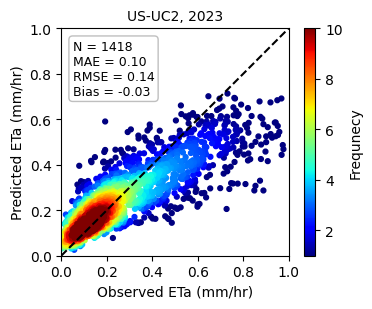

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from matplotlib.ticker import FormatStrFormatter

# Assuming df['actual'] and df['predicted'] exist
x = UC2_df_test_w_preds.loc['2023']['ETa_corr'].values
y = UC2_df_test_w_preds.loc['2023']['ETa_predicted'].values


# Stack them and calculate the point density
xy = np.vstack([x, y])
kde = gaussian_kde(xy)
kde.set_bandwidth(bw_method=0.3)
z = kde(xy)  # z is the density estimate
# Optional: sort so densest points are plotted last (on top)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

# Error metrics
n = len(x)
r2 = r2_score(x, y)
mae = mean_absolute_error(x, y)
rmse = np.sqrt(mean_squared_error(x, y))
bias = np.mean(y - x)

# Plot
plt.figure(figsize=(4,3.2))
sc = plt.scatter(x, y, c=z, cmap='jet', s=12, vmin=1, vmax=10)
plt.colorbar(sc, label='Frequnecy')
plt.plot([0, 1], [0, 1], linestyle='--', color='black')

textstr = f'N = {n}\nMAE = {mae:.2f}\nRMSE = {rmse:.2f}\nBias = {bias:0.2f}'
plt.text(
    0.05, 0.95, textstr,
    transform=plt.gca().transAxes,  # Use axes coords (0–1)
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray',alpha=0.5)
)

# Set square plot area
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plt.xlabel('Observed ETa (mm/hr)')
plt.ylabel('Predicted ETa (mm/hr)')
plt.xlim(0,1)
plt.ylim(0,1)
plt.title('US-UC2, 2023', fontsize=10)
xmin, xmax = plt.gca().get_xlim()
ymin, ymax = plt.gca().get_ylim()

N = 6   # number of ticks

plt.xticks(np.linspace(xmin, xmax, N))
plt.yticks(np.linspace(ymin, ymax, N))
#plt.legend()
plt.tight_layout()
plt.savefig('US_UC2_2023_Actual_vs_Predcited_ETa_plot_with_colorbar.png', dpi=300, transparent=True)
plt.show()

In [20]:
final_model.params

{'boosting': 'gbdt',
 'objective': 'huber',
 'metric': ['huber'],
 'tree_learner': 'serial',
 'device_type': 'cpu',
 'data_sample_strategy': 'bagging',
 'num_iterations': 5000,
 'learning_rate': 0.0032953,
 'num_leaves': 60,
 'num_threads': 0,
 'seed': 0,
 'deterministic': False,
 'force_col_wise': False,
 'force_row_wise': False,
 'histogram_pool_size': -1,
 'max_depth': 23,
 'min_data_in_leaf': 20,
 'min_sum_hessian_in_leaf': 0.001,
 'bagging_fraction': 0.99864,
 'pos_bagging_fraction': 1,
 'neg_bagging_fraction': 1,
 'bagging_freq': 4,
 'bagging_seed': 3,
 'bagging_by_query': False,
 'feature_fraction': 0.898115,
 'feature_fraction_bynode': 1,
 'feature_fraction_seed': 2,
 'extra_trees': False,
 'extra_seed': 6,
 'early_stopping_round': 0,
 'early_stopping_min_delta': 0,
 'first_metric_only': False,
 'max_delta_step': 0,
 'lambda_l1': 0.100384,
 'lambda_l2': 0.0971247,
 'linear_lambda': 0,
 'min_gain_to_split': 0,
 'drop_rate': 0.1,
 'max_drop': 50,
 'skip_drop': 0.5,
 'xgboost_dart